In [1]:
# IMPORTS

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
from pathlib import Path
import os
import importlib

# nomad modules
import nomad.io.base as loader
import nomad.data as data_folder
import nomad.filters as filters

import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.density_based as SEQSCAN
import nomad.stop_detection.hdbscan as HDBSCAN
import nomad.stop_detection.dbscan as DBSCAN
import nomad.stop_detection.grid_based as GRID_BASED

import nomad.stop_detection.viz as viz
importlib.reload(viz)

animate_stop_dashboard = viz.animate_stop_dashboard

In [2]:
# LOAD BASE DATA

data_dir = Path(data_folder.__file__).parent
city_path = data_dir / "garden-city-buildings-mercator.parquet"
city = gpd.read_parquet(city_path)

tc = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "unix_ts"
}

In [3]:
# GENERATE REPRODUCIBLE TRAJECTORY

# nomad/data for packaged static data
# examples/ for demo traj data

# Select specific user & date to load a consistent, reproducible trajectory.
# If instead want to generate a traj at random --> replace with 'None'

repo_root = Path(data_folder.__file__).resolve().parents[2]
traj_path = repo_root / "examples" / "gc_data_long"

demo_user = "admiring_brattain"
demo_date = "2024-01-01"

traj = loader.sample_from_file(
    traj_path,
    format="parquet",
    users=[demo_user],
    filters=("date", "==", demo_date),
    traj_cols=tc
)

print(traj.head())
print(traj.columns)
print(len(traj))

       gc_identifier         dev_x         dev_y     unix_ts         ha  \
0  admiring_brattain -4.265481e+06  4.393146e+06  1704106881  10.702426   
1  admiring_brattain -4.265533e+06  4.393159e+06  1704107003  19.015804   
2  admiring_brattain -4.265477e+06  4.393185e+06  1704107072  24.851835   
3  admiring_brattain -4.265490e+06  4.393156e+06  1704107268  10.181171   
4  admiring_brattain -4.265491e+06  4.393147e+06  1704107349  11.100491   

   tz_offset        date  
0     -14400  2024-01-01  
1     -14400  2024-01-01  
2     -14400  2024-01-01  
3     -14400  2024-01-01  
4     -14400  2024-01-01  
Index(['gc_identifier', 'dev_x', 'dev_y', 'unix_ts', 'ha', 'tz_offset',
       'date'],
      dtype='str')
96


### Lachesis

In [4]:
# RUN LACHESIS STOP DETECTION 

stops = LACHESIS.lachesis(
    traj,
    delta_roam=20,
    dt_max=60,
    dur_min=5,
    complete_output=True,
    keep_col_names=True,
    traj_cols=tc
)

print(stops.head())
print(stops.columns)
print(len(stops))

   cluster             x             y     unix_ts         ha   diameter  \
0        0 -4.265482e+06  4.393153e+06  1704107777  11.006086  14.820705   
1        1 -4.265478e+06  4.393120e+06  1704112028  11.038392  16.458197   
2        2 -4.265482e+06  4.393117e+06  1704112843  12.200451  18.663269   
3        3 -4.265475e+06  4.393110e+06  1704113482   9.792796   8.638411   
4        4 -4.265449e+06  4.393130e+06  1704114942  11.163325  17.188732   

   n_pings  end_timestamp  duration  max_gap      gc_identifier  
0        3     1704108899        18       12  admiring_brattain  
1        6     1704112657        10        3  admiring_brattain  
2        4     1704113143         5        3  admiring_brattain  
3        3     1704113875         6        6  admiring_brattain  
4        6     1704116038        18        7  admiring_brattain  
Index(['cluster', 'x', 'y', 'unix_ts', 'ha', 'diameter', 'n_pings',
       'end_timestamp', 'duration', 'max_gap', 'gc_identifier'],
      dtype='s

In [5]:
# CLEAN UP

# standardize timestamp column for anim
stops_anim = stops.rename(columns={'unix_ts': 'timestamp'}).copy()
traj_anim = traj.rename(columns={'unix_ts': 'timestamp'}).copy()

# assign ping to noise if not inside a detected stop
traj_anim['cluster'] = -1  

# maps each stop interval 
for _, stop in stops_anim.iterrows():
    mask = (
        (traj_anim['timestamp'] >= stop['timestamp']) &
        (traj_anim['timestamp'] <= stop['end_timestamp'])
    )
    traj_anim.loc[mask, 'cluster'] = stop['cluster']

# animation specific column mapping
tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}

In [6]:
%%capture

anim_lach = animate_stop_dashboard(
    data=traj_anim,
    stops=stops_anim,
    save_path="lachesis_test.gif",
    traj_cols=tc_anim,
    show_path=False,
    show_stop_overlays=False,
    ping_color="cluster",
    ping_cmap="tab10",
    ping_size=20,
    base_geometry=city,
    base_geom_color="#d9d9d9",
    base_geom_background="#f2f2f2",
    stop_color="cluster_color"
)

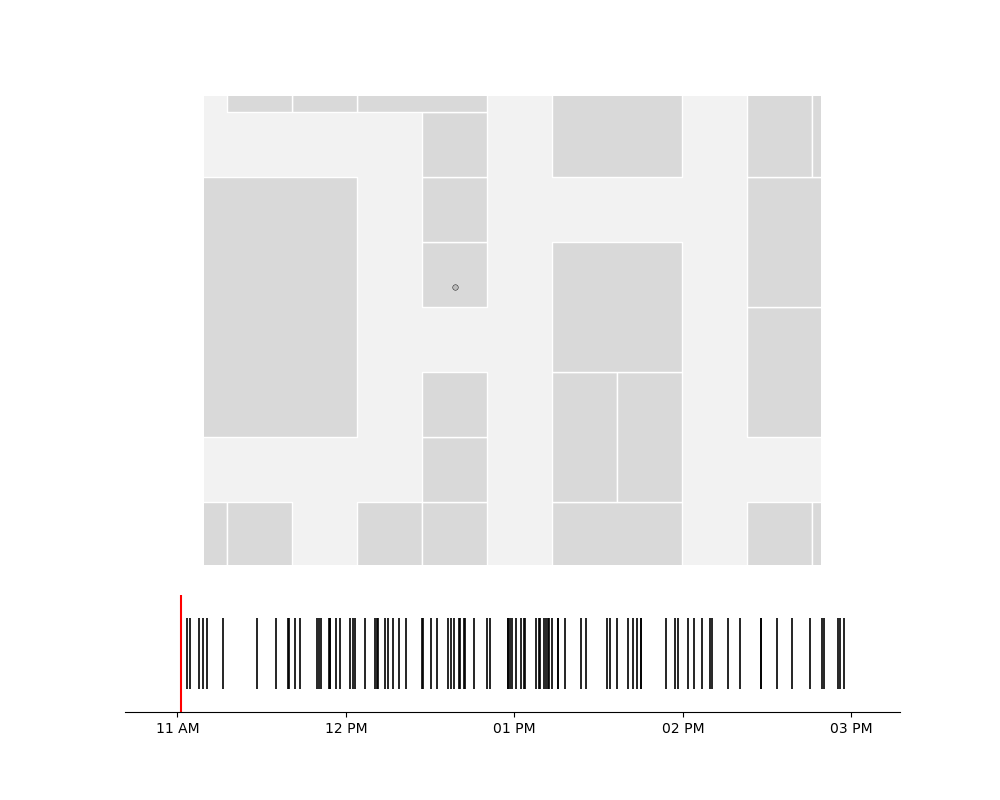

In [7]:
from IPython.display import Image
Image(filename="lachesis_test.gif")

### SeqScan

In [8]:
# RUN STOP DETECTION (SEQSCAN)

stops_seqscan = SEQSCAN.seqscan(
    traj,
    time_thresh=60,
    dist_thresh=8,
    min_pts=3,
    complete_output=True,
    traj_cols=tc
)

print(stops_seqscan.head())
print(stops_seqscan.columns.tolist())
print(len(stops_seqscan))

   cluster             x             y     unix_ts         ha   diameter  \
0        0 -4.265483e+06  4.393152e+06  1704107268  15.428344  17.490164   
1        1 -4.265479e+06  4.393109e+06  1704110542  10.904197  22.963333   
2        2 -4.265444e+06  4.393141e+06  1704114212  11.838617  30.268388   
3        3 -4.265442e+06  4.393104e+06  1704118232  12.179614  21.014442   

   n_pings  end_timestamp  duration  max_gap      gc_identifier  
0        6     1704109867        43       17  admiring_brattain  
1       14     1704114036        58       15  admiring_brattain  
2       12     1704117441        53        9  admiring_brattain  
3        8     1704121040        46       21  admiring_brattain  
['cluster', 'x', 'y', 'unix_ts', 'ha', 'diameter', 'n_pings', 'end_timestamp', 'duration', 'max_gap', 'gc_identifier']
4


In [9]:
# PREPARE ANIMATION INPUTS (SEQSCAN)

traj_anim = traj.rename(columns={"unix_ts": "timestamp"}).copy()
stops_seqscan_anim = stops_seqscan.rename(columns={"unix_ts": "timestamp"}).copy()

traj_anim["cluster"] = -1

for _, stop in stops_seqscan_anim.iterrows():
    mask = (
        (traj_anim["timestamp"] >= stop["timestamp"]) &
        (traj_anim["timestamp"] <= stop["end_timestamp"])
    )
    traj_anim.loc[mask, "cluster"] = stop["cluster"]

tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}

In [10]:
%%capture

anim_seq = animate_stop_dashboard(
    data=traj_anim,
    stops=stops_seqscan_anim,
    save_path="seqscan_test.gif",
    traj_cols=tc_anim,
    show_path=False,
    show_stop_overlays=False,
    ping_color="cluster",
    ping_cmap="tab10",
    ping_size=10,
    base_geometry=city,
    base_geom_color="#d9d9d9",
    base_geom_background="#f2f2f2",
    stop_color="cluster_color"
)

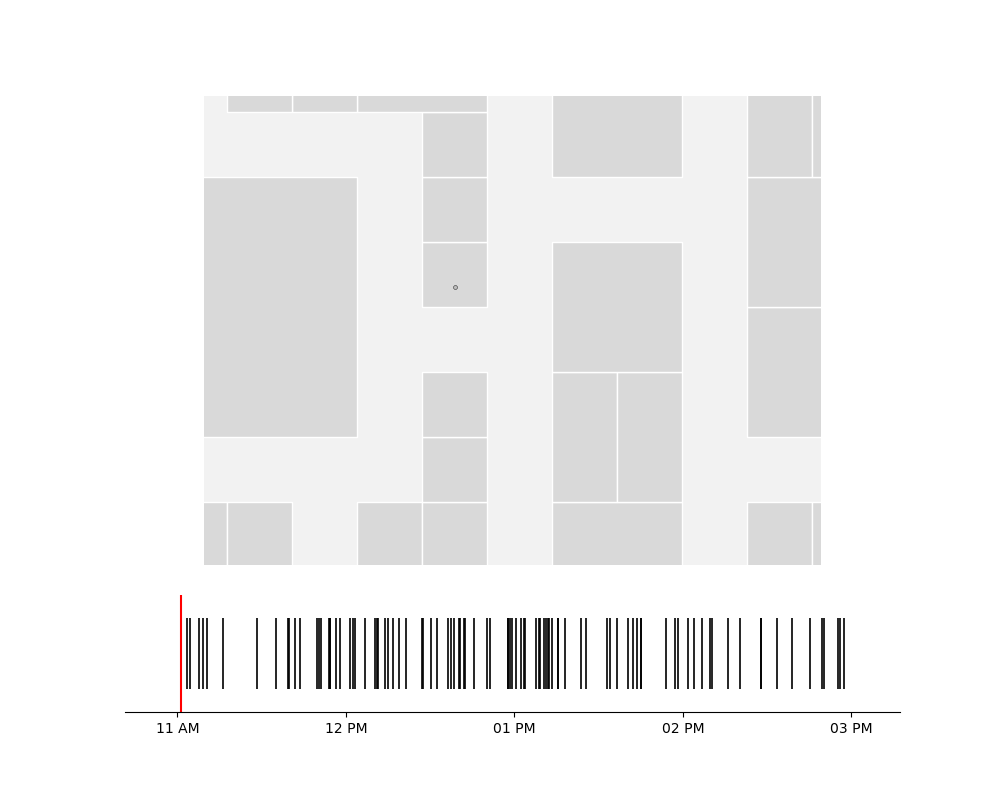

In [11]:
from IPython.display import Image
Image(filename="seqscan_test.gif")

### HDBSCAN

In [12]:
# RUN STOP DETECTION (HDBSCAN)

stops_hdb = HDBSCAN.st_hdbscan(
    traj,
    time_thresh=720,
    min_pts=3,
    complete_output=True,
    traj_cols=tc
)

print(stops_hdb.head())
print(stops_hdb.columns.tolist())
print(len(stops_hdb))

   cluster             x             y     unix_ts         ha   diameter  \
0        2 -4.265482e+06  4.393122e+06  1704106881  11.592257  55.154559   
1        1 -4.265449e+06  4.393124e+06  1704110046  13.917953  58.709114   

   n_pings  end_timestamp  duration  max_gap      gc_identifier  
0       39     1704116192       155       35  admiring_brattain  
1       39     1704121040       183       39  admiring_brattain  
['cluster', 'x', 'y', 'unix_ts', 'ha', 'diameter', 'n_pings', 'end_timestamp', 'duration', 'max_gap', 'gc_identifier']
2


In [13]:
# PREPARE ANIMATION INPUTS (HDBSCAN)

traj_anim = traj.rename(columns={"unix_ts": "timestamp"}).copy()
stops_hdb_anim = stops_hdb.rename(columns={"unix_ts": "timestamp"}).copy()

traj_anim["cluster"] = -1

for _, stop in stops_hdb_anim.iterrows():
    mask = (
        (traj_anim["timestamp"] >= stop["timestamp"]) &
        (traj_anim["timestamp"] <= stop["end_timestamp"])
    )
    traj_anim.loc[mask, "cluster"] = stop["cluster"]

tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}

In [14]:
%%capture

anim_hdb = animate_stop_dashboard(
    data=traj_anim,
    stops=stops_hdb_anim,
    save_path="hdbscan_test.gif",
    traj_cols=tc_anim,
    show_path=False,
    show_stop_overlays=False,
    ping_color="cluster",
    ping_cmap="tab10",
    ping_size=10,
    base_geometry=city,
    base_geom_color="#d9d9d9",
    base_geom_background="#f2f2f2",
    stop_color="cluster_color"
)

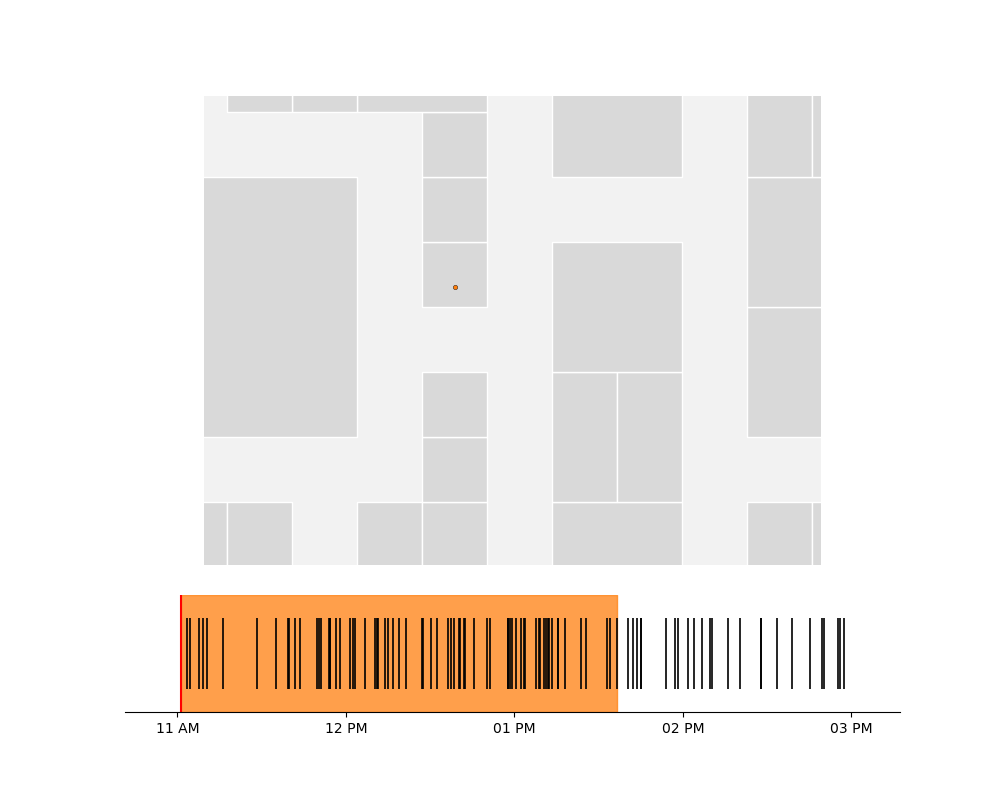

In [15]:
from IPython.display import Image
Image(filename="hdbscan_test.gif")

### TADBSCAN

In [16]:
# RUN STOP DETECTION (TA-DBSCAN)

stops_tadb = DBSCAN.ta_dbscan(
    traj,
    time_thresh=60,
    dist_thresh=10,
    min_pts=3,
    complete_output=True,
    traj_cols=tc
)

print(stops_tadb.head())
print(stops_tadb.columns.tolist())
print(len(stops_tadb))

   cluster             x             y     unix_ts         ha   diameter  \
0        0 -4.265481e+06  4.393146e+06  1704106881  12.063766  53.421270   
2        2 -4.265482e+06  4.393117e+06  1704111064  12.412725  34.995701   
4        4 -4.265476e+06  4.393116e+06  1704113482   9.867250  23.089836   
5        5 -4.265445e+06  4.393133e+06  1704114212  12.643409  58.709114   

   n_pings  end_timestamp  duration  max_gap      gc_identifier  
0       18     1704110595        61       12  admiring_brattain  
2       17     1704113143        34        8  admiring_brattain  
4        6     1704114036         9        6  admiring_brattain  
5       40     1704121040       113       10  admiring_brattain  
['cluster', 'x', 'y', 'unix_ts', 'ha', 'diameter', 'n_pings', 'end_timestamp', 'duration', 'max_gap', 'gc_identifier']
4


In [17]:
"""traj_anim = traj.rename(columns={'unix_ts': 'timestamp'}).copy()
stops_tadb_anim = stops_tadb.rename(columns={'unix_ts': 'timestamp'}).copy()

tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}"""

# PREPARE ANIMATION INPUTS (TA-DBSCAN)

traj_anim = traj.rename(columns={"unix_ts": "timestamp"}).copy()
stops_tadb_anim = stops_tadb.rename(columns={"unix_ts": "timestamp"}).copy()

traj_anim["cluster"] = -1

for _, stop in stops_tadb_anim.iterrows():
    mask = (
        (traj_anim["timestamp"] >= stop["timestamp"]) &
        (traj_anim["timestamp"] <= stop["end_timestamp"])
    )
    traj_anim.loc[mask, "cluster"] = stop["cluster"]

tc_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}

In [18]:
%%capture

anim_tadb = animate_stop_dashboard(
    data=traj_anim,
    stops=stops_tadb_anim,
    save_path="tadbscan_test.gif",
    traj_cols=tc_anim,
    show_path=False,
    show_stop_overlays=False,
    ping_color="cluster",
    ping_cmap="tab10",
    ping_size=10,
    base_geometry=city,
    base_geom_color="#d9d9d9",
    base_geom_background="#f2f2f2",
    stop_color="cluster_color"
)

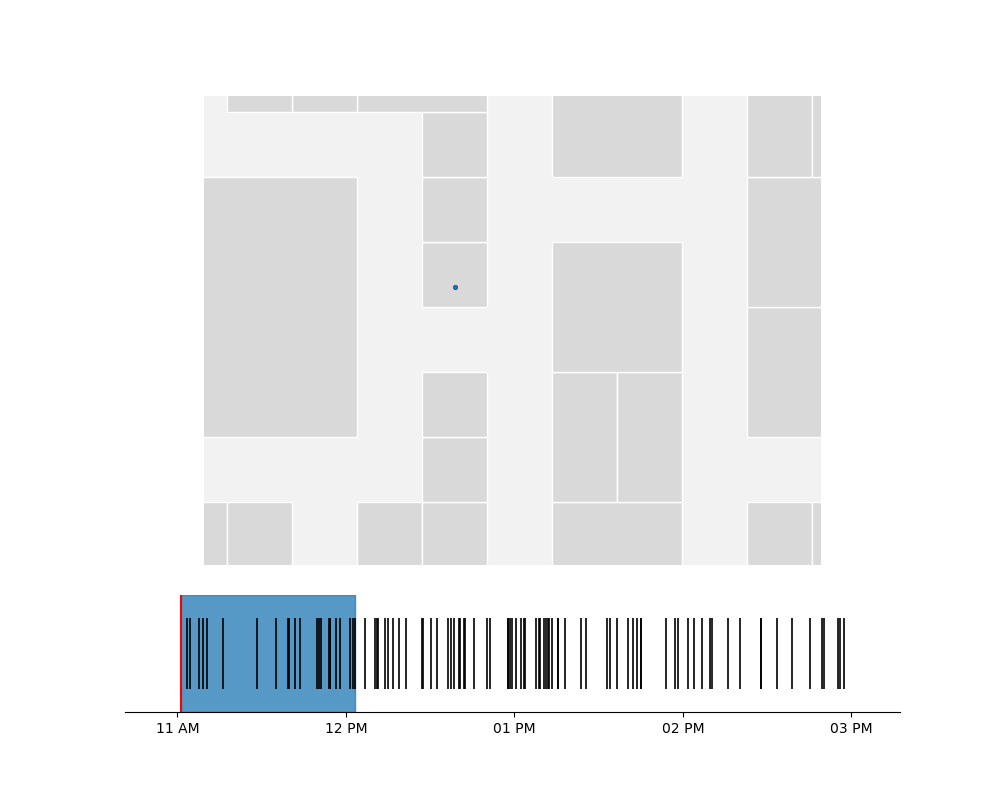

In [19]:
from IPython.display import Image
Image(filename="tadbscan_test.gif")

### Grid Based

In [20]:
# create H3 tessellation column

traj_gb = traj.copy()
traj_gb['h3_cell'] = filters.to_tessellation(
    traj_gb,
    index="h3",
    res=11,
    traj_cols=tc,
    data_crs='EPSG:3857'
)

# RUN STOP DETECTION (Grid-Based)

stops_gb = GRID_BASED.grid_based(
    traj_gb,
    time_thresh=240,
    complete_output=True,
    location_id='h3_cell',
    traj_cols=tc
)

print(stops_gb.head())
print(stops_gb.columns.tolist())
print(len(stops_gb))

   cluster     unix_ts  duration  end_timestamp  n_pings  max_gap  \
0        0  1704107072        30     1704108899        7       12   
1        1  1704109180        11     1704109867        6        6   
2        2  1704110542         9     1704111089        6        3   
3        3  1704112028        18     1704113143       12        3   
4        4  1704113482         9     1704114036        6        6   

           h3_cell  
0  8b3593605ad1fff  
1  8b3593605ad1fff  
2  8b3593605adefff  
3  8b3593605adefff  
4  8b3593605adefff  
['cluster', 'unix_ts', 'duration', 'end_timestamp', 'n_pings', 'max_gap', 'h3_cell']
8


In [21]:
"""traj_gb_anim = traj_gb.rename(columns={'unix_ts': 'timestamp'}).copy()
stops_gb_anim = stops_gb.rename(columns={'unix_ts': 'timestamp'}).copy()

tc_gb_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}"""

# PREPARE ANIMATION INPUTS (GRID-BASED)

traj_gb_anim = traj_gb.rename(columns={"unix_ts": "timestamp"}).copy()
stops_gb_anim = stops_gb.rename(columns={"unix_ts": "timestamp"}).copy()

traj_gb_anim["cluster"] = -1

for _, stop in stops_gb_anim.iterrows():
    mask = (
        (traj_gb_anim["timestamp"] >= stop["timestamp"]) &
        (traj_gb_anim["timestamp"] <= stop["end_timestamp"])
    )
    traj_gb_anim.loc[mask, "cluster"] = stop["cluster"]

tc_gb_anim = {
    "user_id": "gc_identifier",
    "x": "dev_x",
    "y": "dev_y",
    "timestamp": "timestamp"
}



In [22]:
%%capture

anim_gb = animate_stop_dashboard(
    data=traj_gb_anim,
    stops=stops_gb_anim,
    save_path="grid_based_test.gif",
    traj_cols=tc_gb_anim,
    show_path=False,
    show_stop_overlays=False,
    ping_color="cluster",
    ping_cmap="tab10",
    ping_size=10,
    base_geometry=city,
    base_geom_color="#d9d9d9",
    base_geom_background="#f2f2f2",
    stop_color="cluster_color"
)

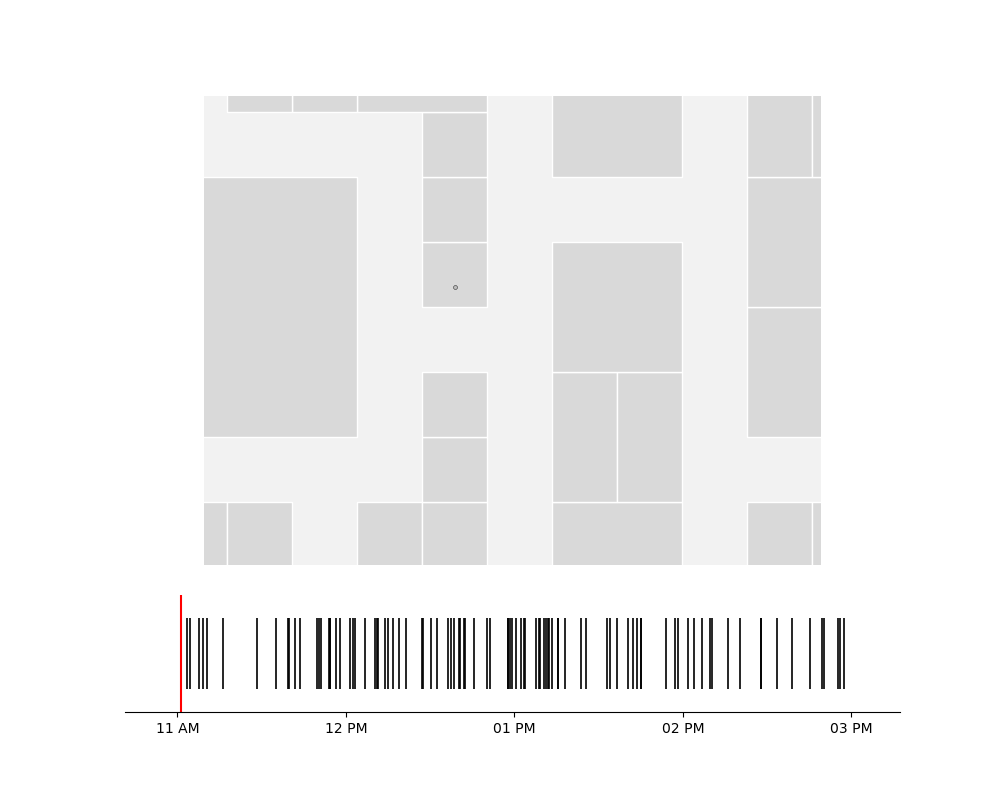

In [23]:
from IPython.display import Image
Image(filename="grid_based_test.gif")